# Curvas ROC y AUC en Python

### Paso 1: Importación de librerías

In [17]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt

### Paso 2: Generación del datase

In [18]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

### Paso 3: División en entrenamiento y prueba

In [19]:
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)

### Paso 4: Modelo base (sin entrenamiento

In [20]:
ns_probs = [0 for _ in range(len(testy))]

### Paso 5: Entrenamiento del modelo

In [21]:
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Paso 6: Predicción de probabilidades

In [22]:
# Predecimos las probabilidades
lr_probs = model.predict_proba(testX)
# Nos quedamos con las probabilidades de la clase positiva (la probabilidad de 1)
lr_probs = lr_probs[:, 1]

### Paso 7: Cálculo del AUC

In [23]:
ns_auc = roc_auc_score(testy, ns_probs)
lr_auc = roc_auc_score(testy, lr_probs)

### Resultado del AUC

In [24]:
# Imprimir en pantalla
print(f"Sin entrenar: ROC AUC={ns_auc:.3f}")
print(f"Regresión logística: ROC AUC={lr_auc:.3f}")

Sin entrenar: ROC AUC=0.500
Regresión logística: ROC AUC=0.903


### Paso 8: Curvas ROC

In [25]:
ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)

### Paso 9: Graficación

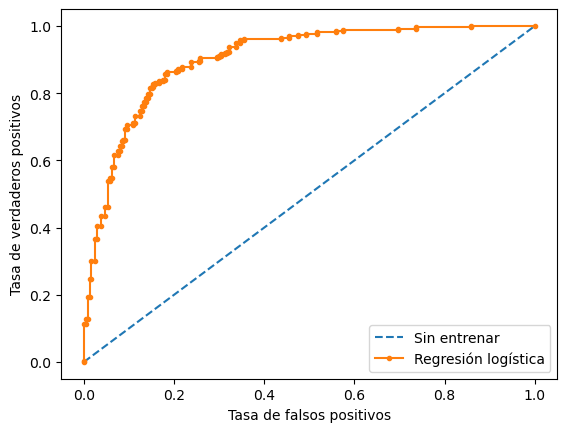

In [26]:
# Graficamos las curvas ROC
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='Sin entrenar')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Regresión logística')
# Etiquetas de los ejes
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend()
plt.show()